<a href="https://colab.research.google.com/github/joaonovo/FIAP_10IADT-tech_challenge_fase_1/blob/main/tech_challenge_fase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 1: Classificação de Risco de AVC

**Pós-Graduação em IA para Devs (10IADT)**
**RM: 375017**

Este notebook apresenta a minha solução completa para o **Tech Challenge B**, cujo objetivo é desenvolver um modelo preditivo para identificar o risco de Acidente Vascular Cerebral (AVC) em pacientes com base em fatores clínicos, demográficos e de estilo de vida, utilizando o *Stroke Prediction Dataset* do Kaggle.

## Estrutura do Trabalho e Justificativa Metodológica

A análise de dados em saúde requer rigor devido ao impacto direto nas decisões clínicas, neste projeto em questão, o enfoque é com base no risco apresentado, auxiliar no processo de priorização do caso para atendimento, fazendo assim que o processo no geral seja mais efetivo.

Estruturei este projeto em 7 etapas principais:

1. **Configuração e Carregamento**: Instalação e importação das dependências.
2. **Análise Exploratória de Dados (EDA)**: Análise técnica das distribuições, correlação visual entre variáveis, identificação de desbalanceamento de classes e matriz de correlação.
3. **Pré-processamento dos Dados**: Separação de treino/teste, imputação de valores ausentes (`bmi`), escalonamento (`StandardScaler`) e tratamento de categóricos usando `OneHotEncoder` via `ColumnTransformer`.
4. **Modelagem e Treinamento**: Implementação e treinamento de 5 modelos robustos: Regressão Logística, Árvore de Decisão, Random Forest, K-Nearest Neighbors (KNN) e Support Vector Machine (SVM), com foco no balanceamento das classes.
5. **Avaliação dos Modelos**: Avaliação comparativa das Matrizes de Confusão para justificar o foco em métricas vitais para a saúde, como Recall (Sensibilidade) e F1-Score, ao invés de Acurácia, como dito na Live de Saúde, não é uma boa métrica para Modelos da área da Saúde.
6. **Explicabilidade do Modelo**: Análise das contribuições das features para cada diagnóstico (utilizando *feature_importances_* e os coeficientes da regressão linear), tornando o modelo clinicamente interpretável.
7. **Exportação do Modelo para Deploy**: Justificativa da escolha do melhor modelo (Random Forest) e exportação do arquivo `.joblib` para consumo via API (FastAPI).



## 1. Configuração e Carregamento dos Dados

Importando as bibliotecas. O dataset será carregado a partir de um link público para garantir a reprodutibilidade.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Dataset
from kagglehub import KaggleDatasetAdapter

# Modelagem e pré-processamento com Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos de Classificação Clássicos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Métricas de Avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, roc_curve, roc_auc_score

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
file_path = "healthcare-dataset-stroke-data.csv"

print("Carregando o dataset do Kaggle...")
try:
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "fedesoriano/stroke-prediction-dataset",
        file_path,
    )
    print("Dataset carregado com sucesso via kagglehub!")
except Exception as e:
    print(f"Erro ao carregar via kagglehub: {e}")
    print("Tentando carregar a partir de Arquivo Local...")
    try:
        df = pd.read_csv('dataset/healthcare-dataset-stroke-data.csv')
        print("Dataset carregado com sucesso via Arquivo")
    except Exception as e_fallback:
        raise RuntimeError(f"Não foi possível obter os dados. Erros: {e} | {e_fallback}")

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Carregando o dataset do Kaggle...
Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Dataset carregado com sucesso via kagglehub!
Dimensões do dataset: 5110 linhas e 12 colunas.


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Análise Exploratória de Dados (EDA)

Nesta etapa, investigo as características do dataset, com foco em entender a distribuição das variáveis, identificar valores ausentes e, principalmente, analisar o desbalanceamento da minha variável-alvo (`stroke`), dentro da saúde este desbalanceamente é considerado normal, visto que normalmente temos mais pacientes *Saúdáveis* que *Doentes*.


In [3]:
print("=== Informações Gerais do DataFrame ===")
df.info()

=== Informações Gerais do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Análise das Informações Gerais (`df.info()`)**<br>
O dataset é composto por 5.110 registros e 12 colunas, contendo uma mistura de variáveis numéricas (`int64`, `float64`) e categóricas (identificadas como `str`, como gênero, tipo de trabalho e status de tabagismo). Noto também que a variável `bmi` (Índice de Massa Corporal) é a única que apresenta uma contagem de valores não nulos inferior ao total (4.909), indicando a presença de dados faltantes que precisarão ser tratados no pré-processamento.

In [4]:
print("\n=== Resumo Estatístico das Variáveis Numéricas ===")
display(df.describe())


=== Resumo Estatístico das Variáveis Numéricas ===


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


**Análise do Resumo Estatístico (`df.describe()`)**<br>
A estatística descritiva revela informações importantes sobre a distribuição das variáveis numéricas. A idade (`age`) varia de bebês (0.08 anos) até 82 anos, com uma média de 43.2 anos. O nível médio de glicose (`avg_glucose_level`) tem média de 106.14, mas atinge picos de até 271.74, o que pode indicar casos de diabetes. Observando a minha variável alvo (`stroke`), a média de 0.0487 já me antecipa que menos de 5% da amostra sofreu um AVC, evidenciando um forte desbalanceamento de classes.

Dados baseados na [pesquisaa](https://www.emro.who.int/health-topics/stroke-cerebrovascular-accident/) da World Health Organization (WHO), mostram que temos algo como 15MM de casos anualmente, um terço destas pessoas, morrem, e um terço apresentam sequelas graves para o resto da vida, pesquisar indicam que quanto mais rapido o tratamento, maior a chance de sobrevivencia e menor a change de sequelas, o Governo do Brasil possui uma [pagina](https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/a/avc) para cocientização desta çondição

In [5]:
print("\n=== Contagem de Valores Ausentes ===")
print(df.isnull().sum())


=== Contagem de Valores Ausentes ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


**Análise de Valores Ausentes (`df.isnull().sum()`)**<br>
A contagem de valores nulos confirma a observação feita anteriormente: a coluna `bmi` possui exatos 201 valores ausentes (aproximadamente 3,9% dos dados). Como as demais variáveis estão completas (0 valores nulos), a etapa de tratamento de dados ausentes precisará focar exclusivamente na melhor estratégia para preencher ou remover os registros faltantes de `bmi` (como a imputação pela média ou mediana).

### 2.1. Análise do Desbalanceamento de Classes

Um dos desafios neste datasets é o desbalanceamento de classes. Casos positivos (como a ocorrência de um AVC) são menores que os negativos.


Casos de Não-AVC (Classe 0): 4861 (95.13%)
Casos de AVC (Classe 1): 249 (4.87%)


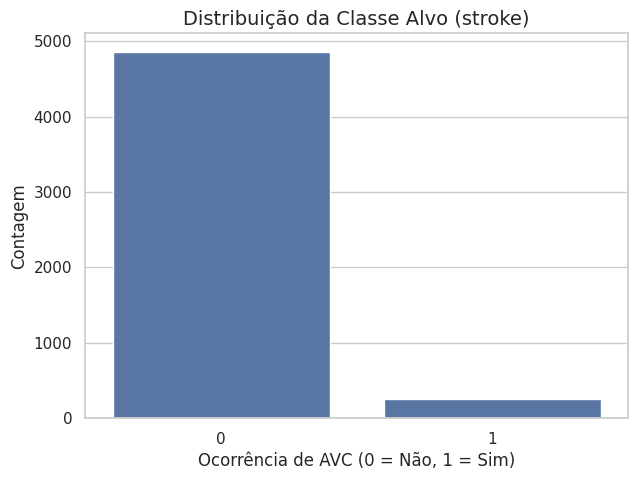

In [6]:
stroke_counts = df['stroke'].value_counts()
stroke_percentages = df['stroke'].value_counts(normalize=True) * 100

print(f"Casos de Não-AVC (Classe 0): {stroke_counts[0]} ({stroke_percentages[0]:.2f}%)")
print(f"Casos de AVC (Classe 1): {stroke_counts[1]} ({stroke_percentages[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='stroke', ax=ax)
ax.set_title("Distribuição da Classe Alvo (stroke)", fontsize=14)
ax.set_xlabel("Ocorrência de AVC (0 = Não, 1 = Sim)")
ax.set_ylabel("Contagem")
plt.show()


Como observado, apenas **4.87%** dos dados correspondem a pacientes que tiveram AVC. Esse desbalanceamento exige atenção na modelagem e na avaliação.


### 2.2. Análise Técnica Fundamentada (Correlação, Distribuição e Features)

A seguir, gero visualizações profundas para embasar minhas decisões metodológicas.

Para que a construção do modelo seja efetiva, não assumimos premissas baseadas na intuição. Mesmo que históricamente pelas pequisas, ideade, tabagismos, pressão alta, são indicadores fortes para predisposição ao AVC. Investigo como cada variável do conjunto se relaciona com a ocorrência de AVC (`stroke=1`).

Primeiro, vou analisar o comportamento das **variáveis categóricas e binárias**. A ideia é observar se certas condições (como doenças prévias, estado civil ou hábitos) apresentam uma proporção visivelmente maior de casos de AVC.

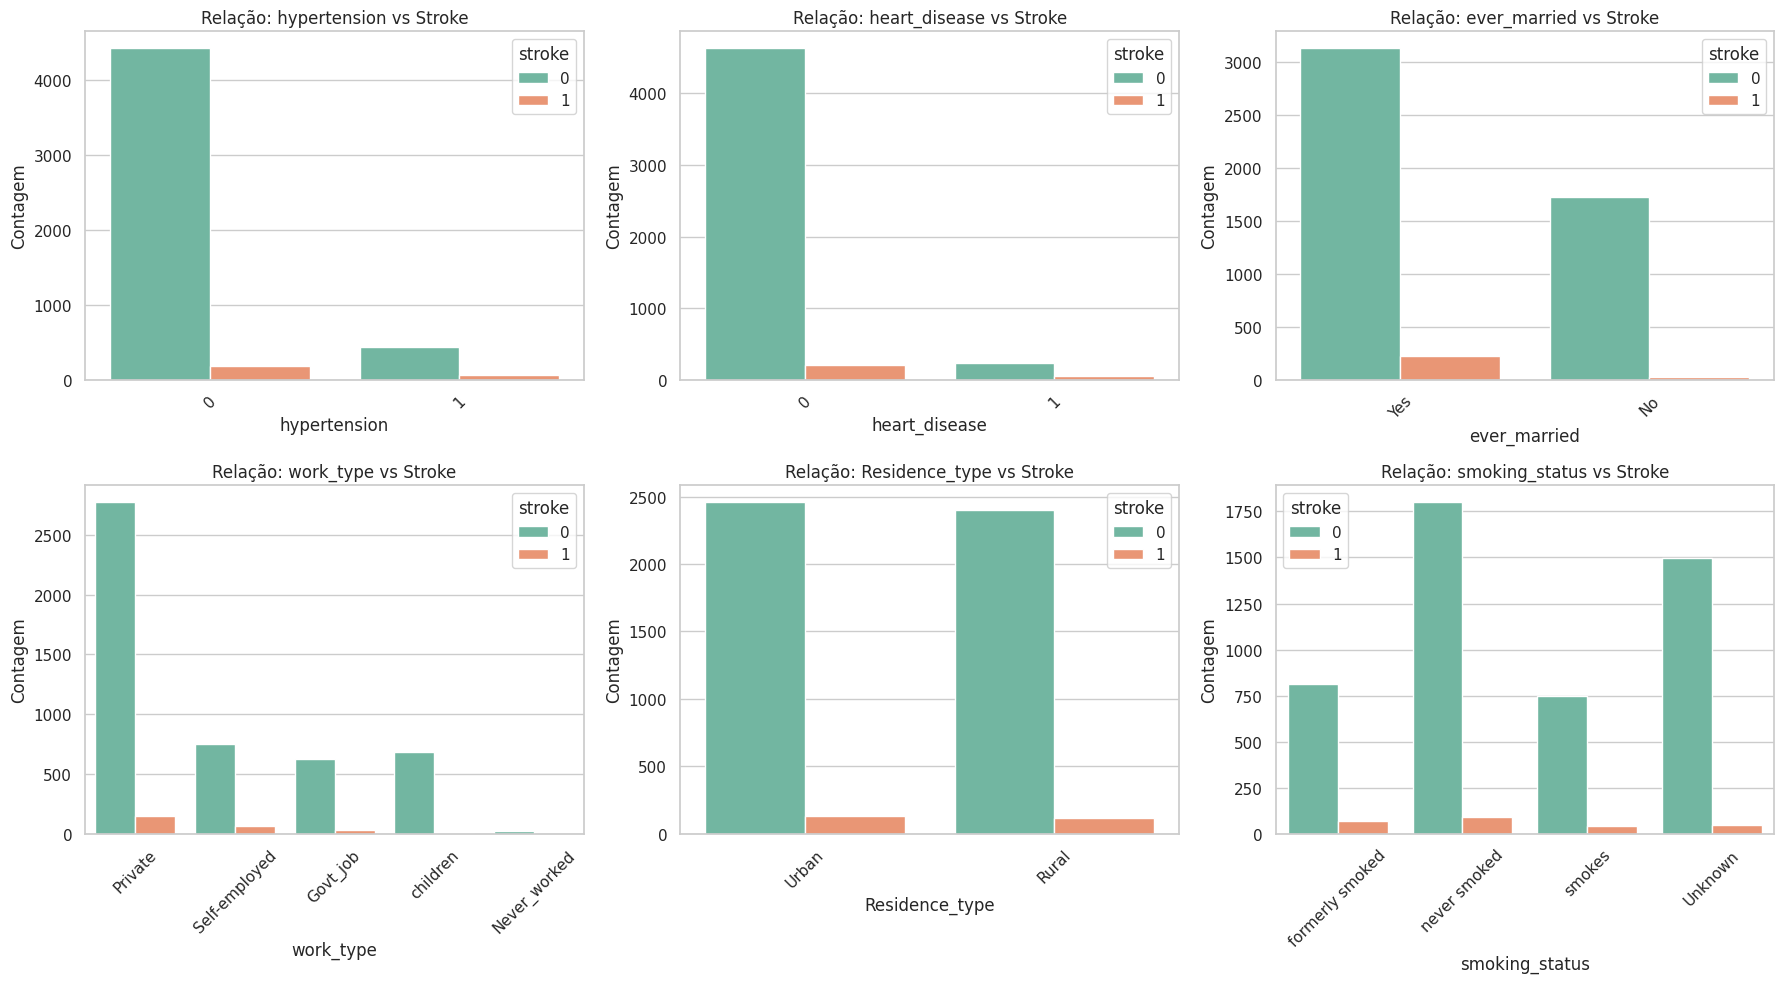

In [7]:
cat_features = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Relação: {col} vs Stroke')
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights Iniciais (Categóricas):**
- Notoriamente, ter **hipertensão** ou **doença cardíaca** (`heart_disease=1`) aumenta a proporção relativa de casos de AVC na amostra.
- Variáveis como `ever_married` (já foi casado) e `work_type` (tipo de trabalho) também mostram diferenças visuais, mas podem estar fortemente ligadas à **idade** (pessoas mais velhas tendem a ser casadas e estar em certos tipos de emprego/aposentadoria).

Em seguida, vou explorar a distribuição das **variáveis numéricas contínuas** (`age`, `avg_glucose_level`, `bmi`) para entender se existe uma clara separação entre pacientes saudáveis e os que sofreram AVC.

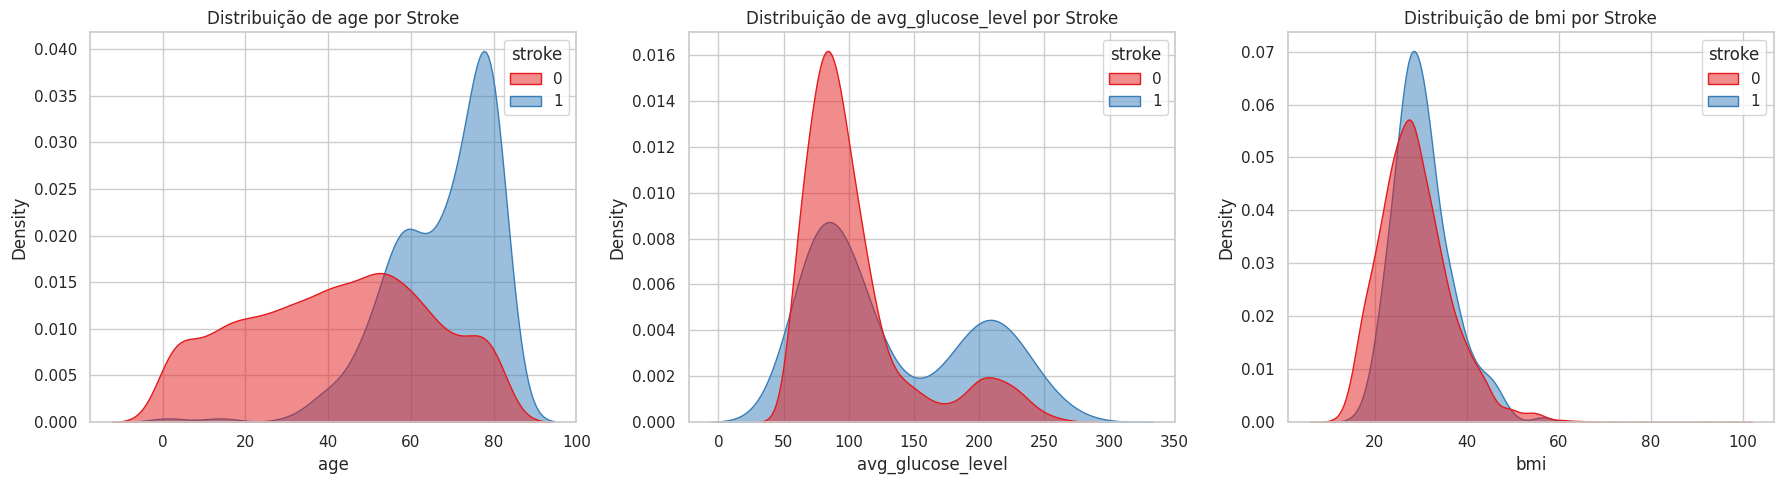

In [8]:
num_features = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_features):
    # common_norm=False para visualizar a densidade de cada classe independentemente do desbalanceamento
    sns.kdeplot(data=df, x=col, hue='stroke', fill=True, common_norm=False, ax=axes[i], palette='Set1', alpha=0.5)
    axes[i].set_title(f'Distribuição de {col} por Stroke')

plt.tight_layout()
plt.show()

**Insights Iniciais (Contínuas):**
- **Idade (`age`)**: Há um claro deslocamento e correlação. Pacientes que sofreram AVC estão fortemente concentrados em idades mais avançadas (acima de 50-60 anos). Esta será, sem dúvida, uma das variáveis mais fortes.
- **Glicose Média (`avg_glucose_level`)**: Observo um comportamento bimodal interessante nos casos de AVC. Há um pico em níveis normais e um segundo pico muito claro em níveis altos de glicose (acima de 150-200). Isso indica que a hiperglicemia/diabetes é um forte diferenciador de risco.
- **IMC (`bmi`)**: O comportamento é bastante similar entre as duas classes, com uma leve tendência de alta no grupo com AVC, mas não é um separador tão drástico visualmente quanto a idade ou a glicose.

Tendo estabelecido através de uma análise individual que **Idade, Glicose e condições pré-existentes (hipertensão/cardíacas)** são grandes indicadores de risco (features mais relevantes), agora preciso verificar se essas variáveis carregam informações redundantes entre si (Multicolinearidade) através de uma **Matriz de Correlação** e analisar potenciais *outliers*.

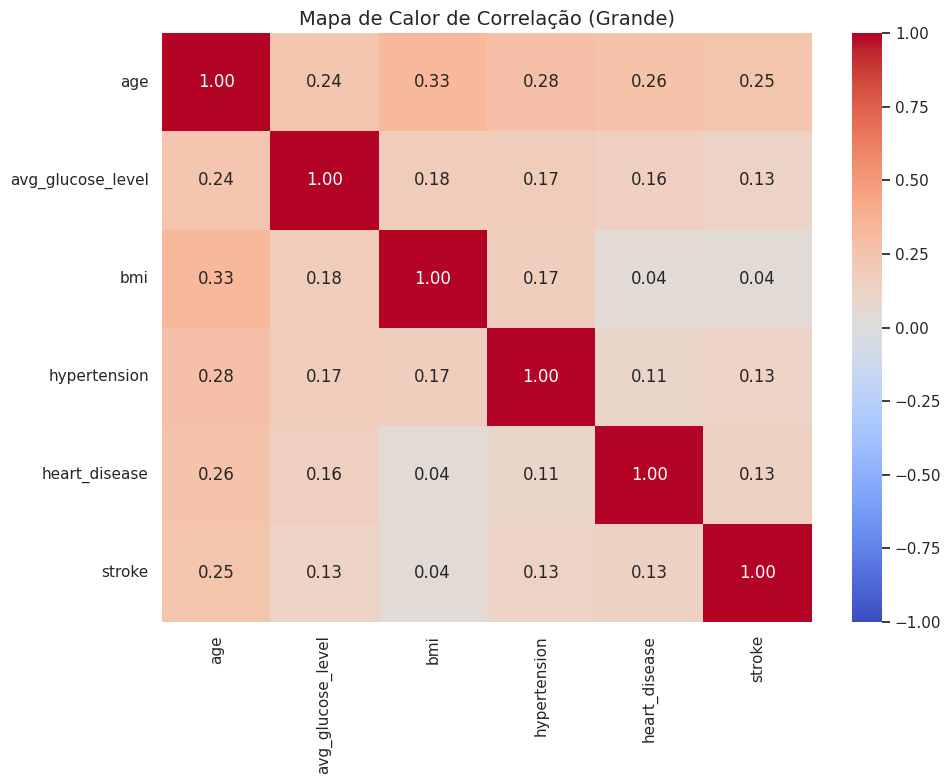

In [9]:
# Seleção de variáveis numéricas para correlação
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

# Calculando a correlação
corr = df[numeric_cols].corr()

# Exibindo o gráfico de correlação grande
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlação (Grande)', fontsize=14)
plt.tight_layout()
plt.show()


### Análise do Gráfico de Correlação

A análise da matriz de correlação acima revela as seguintes relações lineares:
- **Idade (`age`) e AVC (`stroke`)**: Apresentam a correlação mais positiva entre os fatores clínicos clássicos (~0.25). Embora pareça um valor moderado, em dados biológicos/saúde é um indicador muito forte de que o avanço da idade é o principal fator de risco linear para o AVC.
- **Idade (`age`) vs IMC (`bmi`) / Hipertensão (`hypertension`) / Doenças Cardíacas (`heart_disease`)**: Vemos correlações positivas moderadas (entre 0.12 e 0.33). Isso reflete que o envelhecimento natural do corpo está associado ao aumento de peso e ao desenvolvimento de comorbidades cardiovasculares secundárias.
- **Multicolinearidade**: Nenhuma das variáveis exibe correlação excessiva (todas abaixo de 0.40). Isso indica que as variáveis são linearmente independentes o suficiente para serem mantidas conjuntamente no modelo, trazendo informações complementares e sem risco de sobreajuste por redundância.


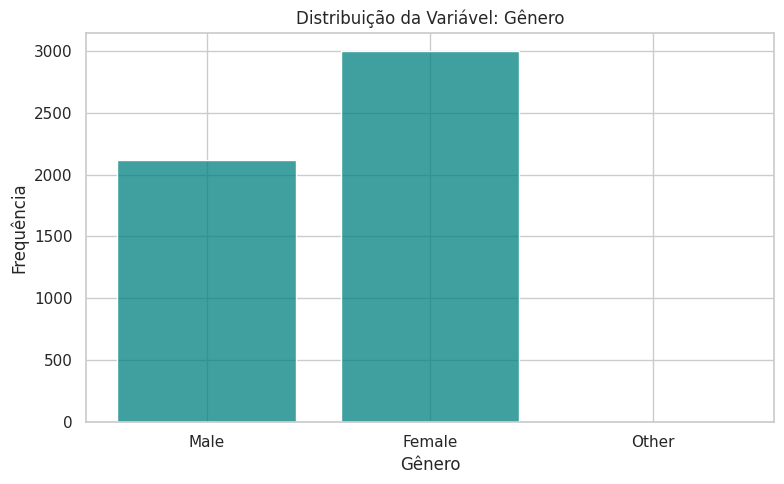

In [10]:
# Distribuição de Gênero
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='gender', shrink=0.8, color='teal')
plt.title('Distribuição da Variável: Gênero', fontsize=12)
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


#### Estudo da Variável: Gênero
- O dataset apresenta uma proporção ligeiramente maior de mulheres (Female) do que homens (Male), além de uma quantidade ínfima/desprezível na categoria 'Other'.
- Essa distribuição é relativamente equilibrada, o que minimiza vieses de gênero nas predições do modelo.


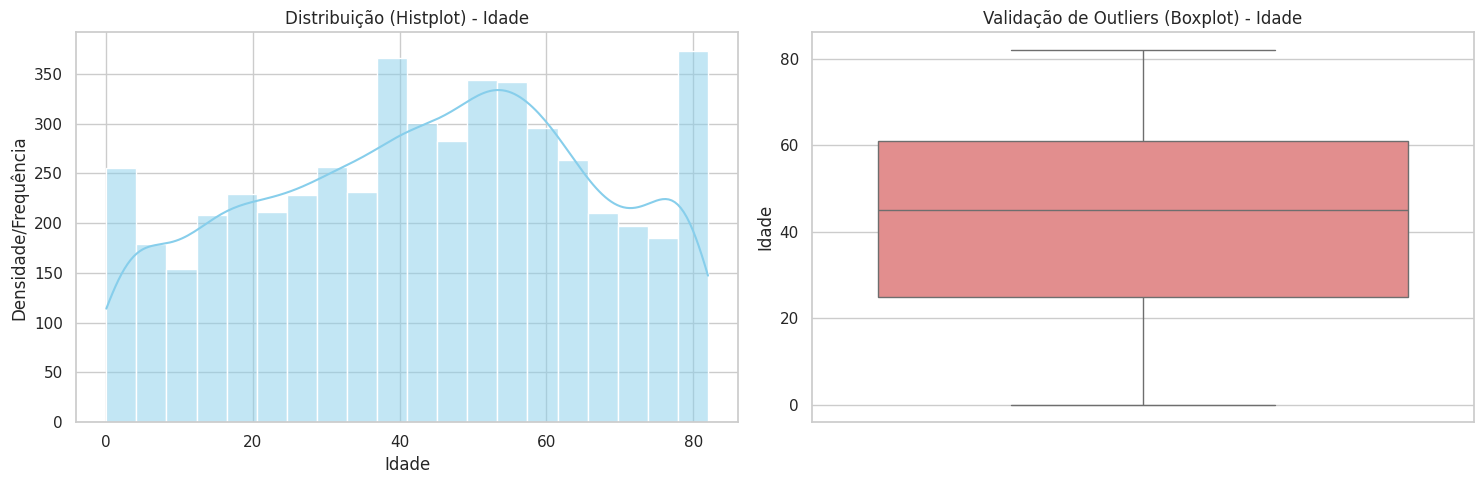

In [11]:
# Distribuição de Idade (Histplot + Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='age', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribuição (Histplot) - Idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Densidade/Frequência')

sns.boxplot(data=df, y='age', color='lightcoral', ax=axes[1])
axes[1].set_title('Validação de Outliers (Boxplot) - Idade')
axes[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()


#### Estudo da Variável: Idade
- **Distribuição**: A idade apresenta uma distribuição ampla e razoavelmente uniforme entre crianças e idosos, com picos sutis na faixa de transição para a fase adulta ativa (40-60 anos).
- **Outliers**: A análise do boxplot revela a **ausência completa de outliers**. O limite superior vai até 82 anos e o inferior até idades próximas a 0 (bebês), faixas que são clinicamente factíveis e representam a realidade da pirâmide etária populacional.


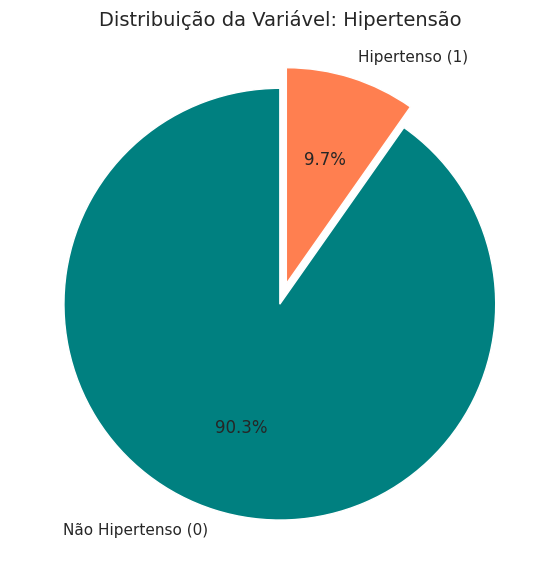

In [12]:
# Distribuição de Hipertensão (Gráfico de Pizza)
plt.figure(figsize=(6, 6))
hypertension_counts = df['hypertension'].value_counts()
plt.pie(hypertension_counts, labels=['Não Hipertenso (0)', 'Hipertenso (1)'], autopct='%1.1f%%', startangle=90, colors=['teal', 'coral'], explode=(0, 0.1))
plt.title('Distribuição da Variável: Hipertensão', fontsize=14)
plt.tight_layout()
plt.show()


#### Estudo da Variável: Hipertensão
- Trata-se de uma variável binária altamente desbalanceada.
- A grande maioria da amostra (cerca de 90%) não sofre de hipertensão. No entanto, a classe positiva (`1`) é de extrema importância clínica, sendo um dos maiores fatores de risco estabelecidos na literatura médica para eventos cerebrovasculares.


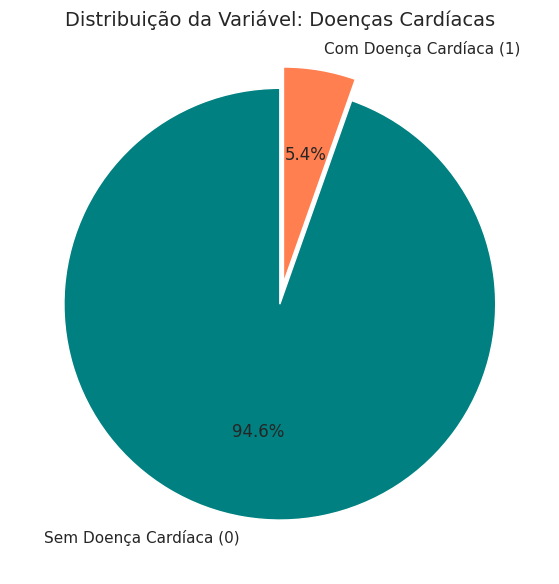

In [13]:
# Distribuição de Doenças Cardíacas (Gráfico de Pizza)
plt.figure(figsize=(6, 6))
heart_disease_counts = df['heart_disease'].value_counts()
plt.pie(heart_disease_counts, labels=['Sem Doença Cardíaca (0)', 'Com Doença Cardíaca (1)'], autopct='%1.1f%%', startangle=90, colors=['teal', 'coral'], explode=(0, 0.1))
plt.title('Distribuição da Variável: Doenças Cardíacas', fontsize=14)
plt.tight_layout()
plt.show()


#### Estudo da Variável: Doenças Cardíacas
- Assim como a hipertensão, a prevalência de doenças cardíacas pré-existentes na base de dados é baixa (~5.4%).
- O modelo deve atentar a essa feature, pois a debilidade do sistema cardiovascular está intrinsecamente ligada à interrupção do fluxo sanguíneo cerebral (isquemia/AVC).


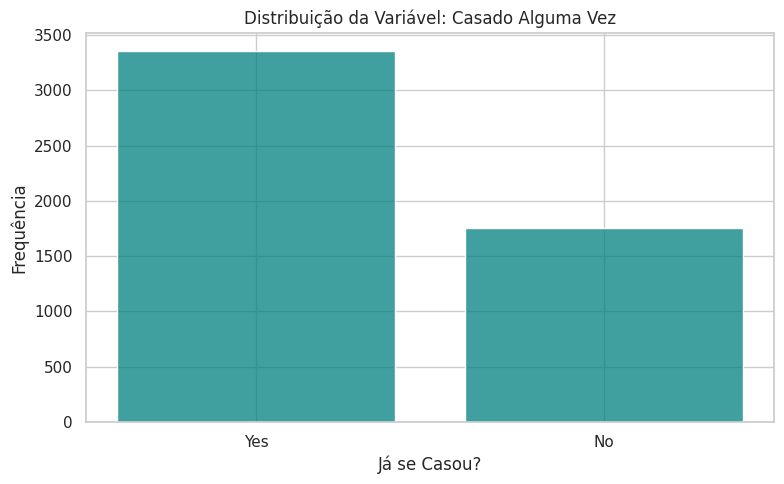

In [14]:
# Distribuição de Casado alguma vez
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='ever_married', shrink=0.8, color='teal')
plt.title('Distribuição da Variável: Casado Alguma Vez', fontsize=12)
plt.xlabel('Já se Casou?')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


#### Estudo da Variável: Casado Alguma Vez
- A maioria das pessoas no dataset já se casou. Essa variável de estilo de vida costuma atuar como um proxy para faixas etárias mais maduras, já que o casamento ocorre predominantemente em adultos.


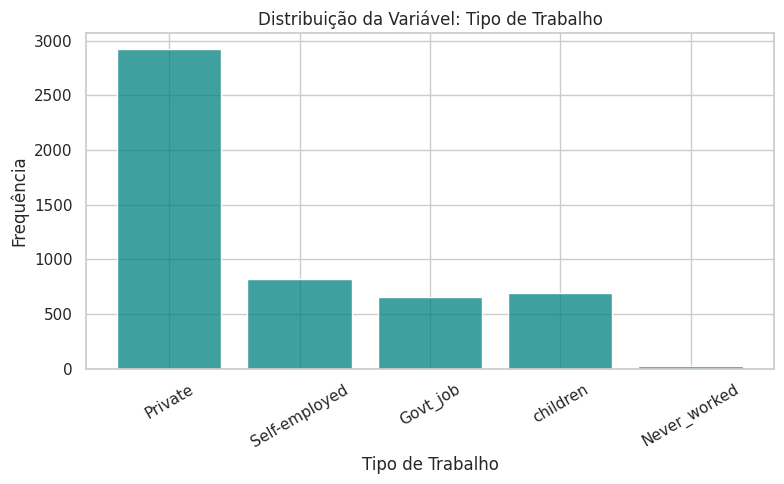

In [15]:
# Distribuição de Tipo de Trabalho
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='work_type', shrink=0.8, color='teal')
plt.title('Distribuição da Variável: Tipo de Trabalho', fontsize=12)
plt.xlabel('Tipo de Trabalho')
plt.ylabel('Frequência')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#### Estudo da Variável: Tipo de Trabalho
- A maior parte dos pacientes atua no setor privado (*Private*), seguido por autônomos (*Self-employed*), empregos governamentais (*Govt_job*) e crianças (*children*). Pessoas que nunca trabalharam formam o menor grupo.
- A categoria *children* serve como marcador de baixa idade, enquanto *Self-employed* costuma englobar idades mais avançadas.


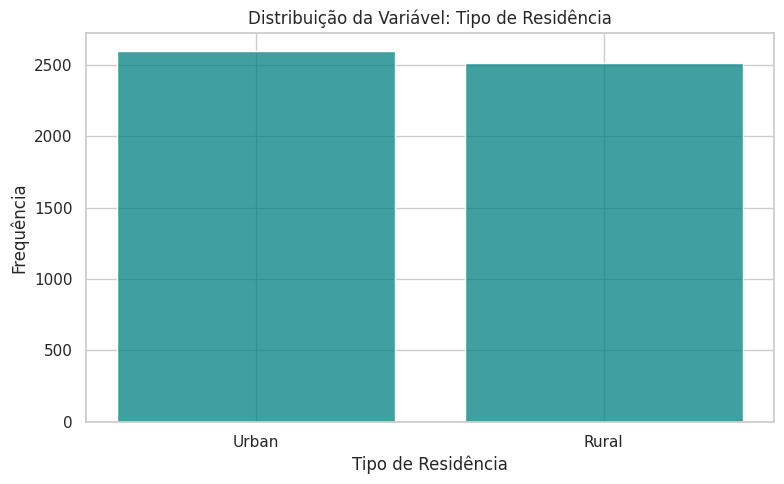

In [16]:
# Distribuição de Tipo de Residência
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Residence_type', shrink=0.8, color='teal')
plt.title('Distribuição da Variável: Tipo de Residência', fontsize=12)
plt.xlabel('Tipo de Residência')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


#### Estudo da Variável: Tipo de Residência
- A amostra é quase perfeitamente equilibrada entre residentes de zonas urbanas e rurais, eliminando distorções geográficas na análise.


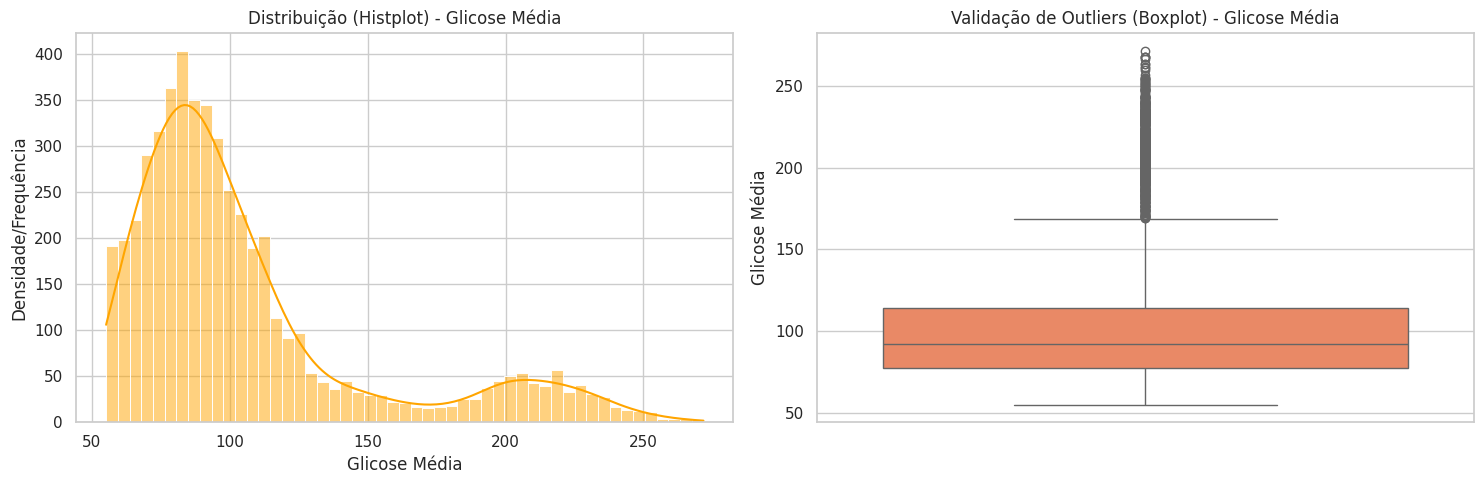

In [17]:
# Distribuição de Glicose Média (Histplot + Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='avg_glucose_level', kde=True, color='orange', ax=axes[0])
axes[0].set_title('Distribuição (Histplot) - Glicose Média')
axes[0].set_xlabel('Glicose Média')
axes[0].set_ylabel('Densidade/Frequência')

sns.boxplot(data=df, y='avg_glucose_level', color='coral', ax=axes[1])
axes[1].set_title('Validação de Outliers (Boxplot) - Glicose Média')
axes[1].set_ylabel('Glicose Média')

plt.tight_layout()
plt.show()


#### Estudo da Variável: Nível Médio de Glicose
- **Distribuição**: Exibe uma assimetria acentuada à direita com um comportamento bimodal. O pico dominante está em faixas normais (80-100 mg/dL), enquanto há um segundo pico/platô na faixa diabética (acima de 200 mg/dL).
- **Outliers**: O boxplot revela **inúmeros outliers na parte superior** (acima de 140 mg/dL). No entanto, estes valores são clinicamente válidos (representam hiperglicemia e diabetes grave) e são cruciais para a predição de AVC, não devendo ser descartados.


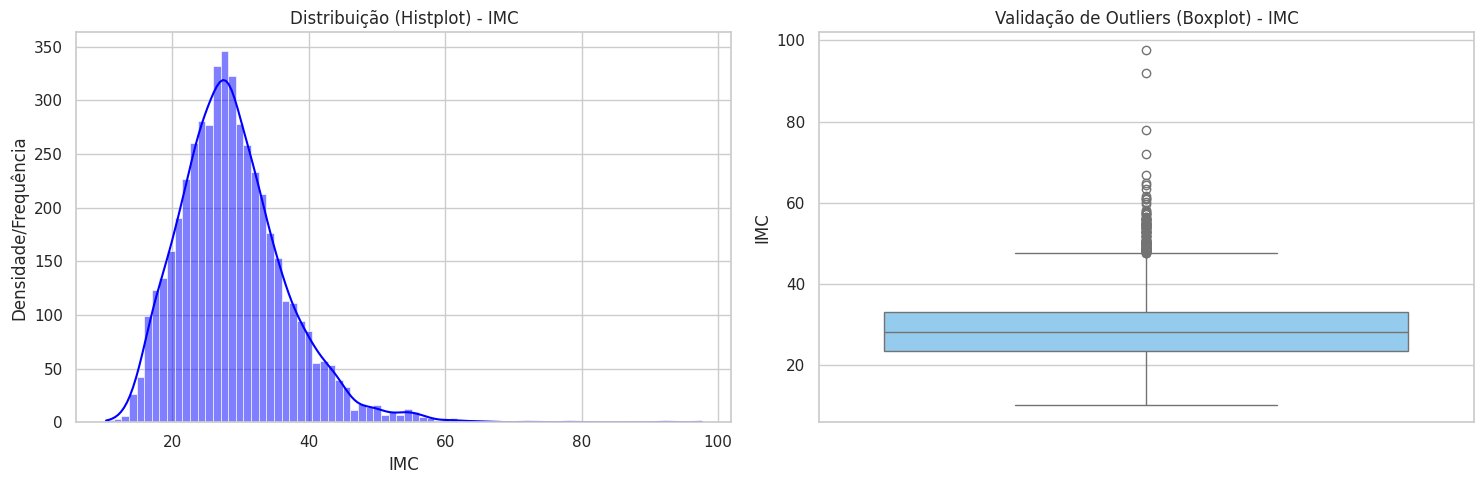

In [18]:
# Distribuição de IMC/BMI (Histplot + Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df['bmi'].dropna(), kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribuição (Histplot) - IMC')
axes[0].set_xlabel('IMC')
axes[0].set_ylabel('Densidade/Frequência')

sns.boxplot(data=df, y='bmi', color='lightskyblue', ax=axes[1])
axes[1].set_title('Validação de Outliers (Boxplot) - IMC')
axes[1].set_ylabel('IMC')

plt.tight_layout()
plt.show()


#### Estudo da Variável: IMC (BMI)
- **Distribuição**: A distribuição aproxima-se de uma normal, ligeiramente deslocada para a direita (média próxima a 28, indicando sobrepeso populacional médio).
- **Outliers**: Há **outliers notáveis na faixa superior** (valores de IMC acima de 45 até perto de 100). Embora alguns valores extremos pareçam erros de registro (IMC > 70 é raríssimo), eles representam obesidade severa, a qual aumenta o risco cardiovascular global.


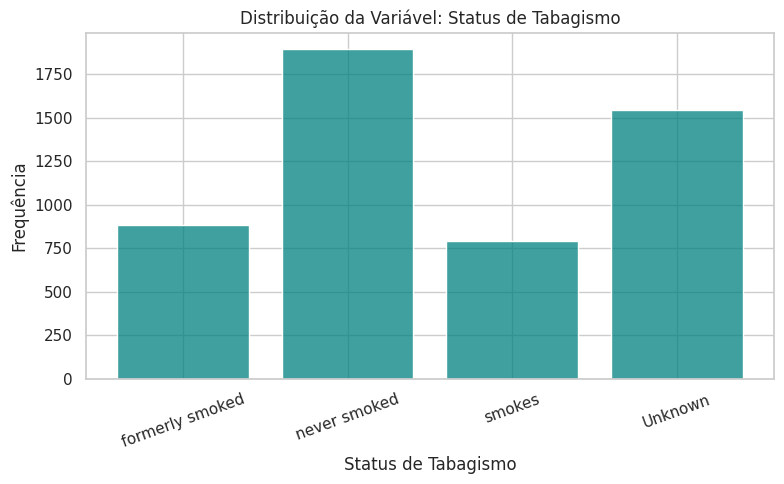

In [19]:
# Distribuição de Status de Tabagismo
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='smoking_status', shrink=0.8, color='teal')
plt.title('Distribuição da Variável: Status de Tabagismo', fontsize=12)
plt.xlabel('Status de Tabagismo')
plt.ylabel('Frequência')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#### Estudo da Variável: Status de Tabagismo
- O grupo mais numeroso é o de pessoas que nunca fumaram (*never smoked*). Um ponto crítico é o alto número de registros 'Unknown', que reflete a ausência de coleta desse dado em anamneses clínicas reais.


### Justificativas Metodológicas para o *Pipeline*

**1. Avaliação de Correlação entre Variáveis**

Ao analisar o *heatmap*, observei que as correlações mais expressivas (como Idade vs. IMC) situam-se próximas a 0.3. Este valor é considerado moderado e clinicamente esperado. Vemos que em linhas gerais os valores de correlações são muito parecidos desta forma não definimos de maneira direta que uma variável pode ser **muito** mais importante que outra. Portanto, **optei por manter todas as variáveis clínicas**, visto que cada uma contribui com uma variância única e relevante para a predição do risco de AVC.

**2. Seleção de Escalonadores: *MinMaxScaler* vs. *StandardScaler***

A análise das distribuições revelou que a **Glicose Média** apresenta uma forte assimetria à direita, com presença de valores extremos (*outliers*) que chegam a 300 (indicativos de casos graves de diabetes).

* O **`MinMaxScaler`** comprime os dados no intervalo [0, 1]. Nesse cenário, os *outliers* seriam mapeados para o valor '1', fazendo com que a grande maioria dos dados (95% da amostra) fosse comprimida em um intervalo muito estreito, comprometendo a riqueza discriminatória do modelo.
* O **`StandardScaler`** centraliza os dados com média 0 e desvio padrão 1. Embora também seja influenciado por *outliers*, ele preserva melhor a distribuição dos dados centrais.

> **Decisão Metodológica:** Dada a natureza dos dados clínicos e a presença de *outliers* biológicos, o **`StandardScaler` é a estratégia de escalonamento mais robusta**.

**3. Pertinência da Aplicação de PCA**

**Não aplicarei o PCA (*Principal Component Analysis*).** Embora seja uma técnica poderosa para redução de dimensionalidade e mitigação da "Maldição da Dimensionalidade", sua aplicação neste *dataset* seria um erro metodológico. No setor de Saúde, a interpretabilidade do modelo é um requisito fundamental; o valor clínico reside em identificar que o risco é elevado devido a um nível glicêmico de 200, e não devido a uma variação em um componente abstrato resultante de uma transformação linear. O ganho marginal em performance não justifica a perda de transparência e interpretabilidade do diagnóstico.

## 3. Pré-processamento dos Dados

Para preparar os dados para os modelos, segui um processo estruturado utilizando o `ColumnTransformer` do Scikit-Learn. Isso garante que as transformações sejam aplicadas de forma consistente.

O pré-processamento inclui:
1.  **Limpeza Inicial**: Remoção da coluna `id`, tratando-se de uma coluna identificadora, talvez utilizada em algum Banco de Dados, não representa um dado importante para o calculo do modelo.
2.  **Divisão dos Dados**: Separação em conjuntos de treino e teste (80/20).
3.  **Imputação de Nulos**: Preenchimento de valores ausentes na coluna `bmi` com a mediana (Explicado anteriormente a motivação da Técnica).
4.  **Codificação de Categóricas**: Conversão de variáveis textuais em numéricas com `OneHotEncoder`. A escolha por esta técnica (em vez de um simples Label Encoding) é metodologicamente fundamental para evitar que o modelo matemático assuma falsas relações de grandeza ou hierarquia entre categorias não ordinais. Por exemplo, se codificarmos os tipos de trabalho como 1, 2 e 3, o modelo pode interpretar erroneamente que o trabalho 3 é "maior" que o trabalho 1. O `OneHotEncoder` contorna isso criando colunas binárias (0 ou 1) totalmente independentes para cada categoria, eliminando esse viés artificial.
5.  **Normalização de Numéricas**: Padronização da feature numericas com `StandardScaler`.


In [20]:
# 1. Limpeza Inicial
df.drop(columns=['id'], inplace=True)

# 2. Divisão dos Dados
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identificação das colunas para cada tipo de transformação
numerical_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# 3, 4, 5. Criação dos pipelines de pré-processamento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Unindo os transformadores com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


## 4. Modelagem e Treinamento

Nesta etapa, vou treinar e comparar cinco modelos de classificação clássicos do Scikit-Learn. A escolha de múltiplos algoritmos com arquiteturas diferentes permite identificar o melhor ajuste para os dados:

1.  **Regressão Logística**: Um modelo linear probabilístico e altamente interpretável. É excelente como baseline porque mostra como as features se relacionam linearmente com o risco de AVC.
2.  **Árvore de Decisão**: Um modelo não-linear que segmenta os dados formando regras de decisão (ex: se Idade > 60 e Glicose > 150). Muito útil por sua explicabilidade visual.
3.  **Random Forest**: Um modelo de *ensemble* que combina múltiplas árvores de decisão. Excelente para lidar com interações complexas entre variáveis, reduzindo o sobreajuste (overfitting) típico de uma árvore única.
4.  **K-Nearest Neighbors (KNN)**: Modelo baseado em instâncias (distância). Ele tenta classificar um paciente buscando os 'k' pacientes mais parecidos no dataset. A aplicação do StandardScaler no pré-processamento é vital aqui, pois distâncias não normalizadas prejudicariam o KNN.
5.  **Support Vector Machine (SVM)**: Um modelo geométrico focado em encontrar o hiperplano de separação máxima entre os saudáveis e doentes. Extremamente efetivo em espaços de alta dimensionalidade gerados pelo OneHotEncoder.

Para lidar com o desbalanceamento de classes, utilizarei o parâmetro `class_weight='balanced'` sempre que o modelo permitir (Regressão Logística, Árvore de Decisão, Random Forest e SVM), garantindo que a classe minoritária (AVC) ganhe mais "peso" durante o treinamento.


In [21]:
# Criando os pipelines completos para cada modelo

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, class_weight='balanced'))
])

# Treinando os modelos
print("Treinando Regressão Logística...")
lr_pipeline.fit(X_train, y_train)

print("Treinando Árvore de Decisão...")
dt_pipeline.fit(X_train, y_train)

print("Treinando Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Treinando K-Nearest Neighbors (KNN)...")
knn_pipeline.fit(X_train, y_train)

print("Treinando Support Vector Machine (SVM)...")
svm_pipeline.fit(X_train, y_train)

print("\nTreinamento concluído!")



Treinando Regressão Logística...
Treinando Árvore de Decisão...
Treinando Random Forest...
Treinando K-Nearest Neighbors (KNN)...
Treinando Support Vector Machine (SVM)...

Treinamento concluído!


## 5. Avaliação dos Modelos

A avaliação é a etapa mais crítica. Como discutido, a acurácia não é uma métrica confiável para este problema. Vou focar em:

-   **Recall (Sensibilidade)**: Essencial para garantir que estou identificando o máximo possível de pacientes com risco de AVC.
-   **F1-Score**: Uma média harmônica entre precisão e recall, que me dá uma visão balanceada do desempenho na classe positiva.
-   **Matriz de Confusão**: Para visualizar diretamente os erros do modelo (Falsos Positivos e Falsos Negativos).


In [22]:
models = {
    "Regressão Logística": lr_pipeline,
    "Árvore de Decisão": dt_pipeline,
    "Random Forest": rf_pipeline,
    "K-Nearest Neighbors (KNN)": knn_pipeline,
    "Support Vector Machine (SVM)": svm_pipeline
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Obter probabilidades ou pontuações de decisão para cálculo de AUC
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except (AttributeError, RuntimeError):
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Modelo": name,
        "Acurácia": accuracy,
        "Recall (Classe 1)": recall,
        "F1-Score (Classe 1)": f1,
        "AUC-ROC": auc
    })

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("\n")

df_results = pd.DataFrame(results).set_index("Modelo")
display(df_results.round(3))


--- Regressão Logística ---
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



--- Árvore de Decisão ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.17      0.12      0.14        50

    accuracy                           0.93      1022
   macro avg       0.56      0.55      0.55      1022
weighted avg       0.92      0.93      0.92      1022



--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49     

,Acurácia,Recall (Classe 1),F1-Score (Classe 1),AUC-ROC
Modelo,,,,
Regressão Logística,0.746,0.80,0.235,0.844
Árvore de Decisão,0.929,0.12,0.141,0.545
Random Forest,0.950,0.00,0.000,0.800
K-Nearest Neighbors (KNN),0.943,0.00,0.000,0.603
Support Vector Machine (SVM),0.750,0.70,0.215,0.803


### 5.1. Análise Comparativa das Matrizes de Confusão

Vou visualizar a matriz de confusão de **todos os modelos treinados**. No contexto clínico, a acurácia isolada mascara os erros em classes raras. Visualizar a quantidade exata de Falsos Negativos (doentes classificados como saudáveis - o pior cenário clínico) e Falsos Positivos (saudáveis classificados como doentes - sobrecarga de exames) é essencial para argumentar de forma sólida qual é o melhor algoritmo para nossa aplicação real.


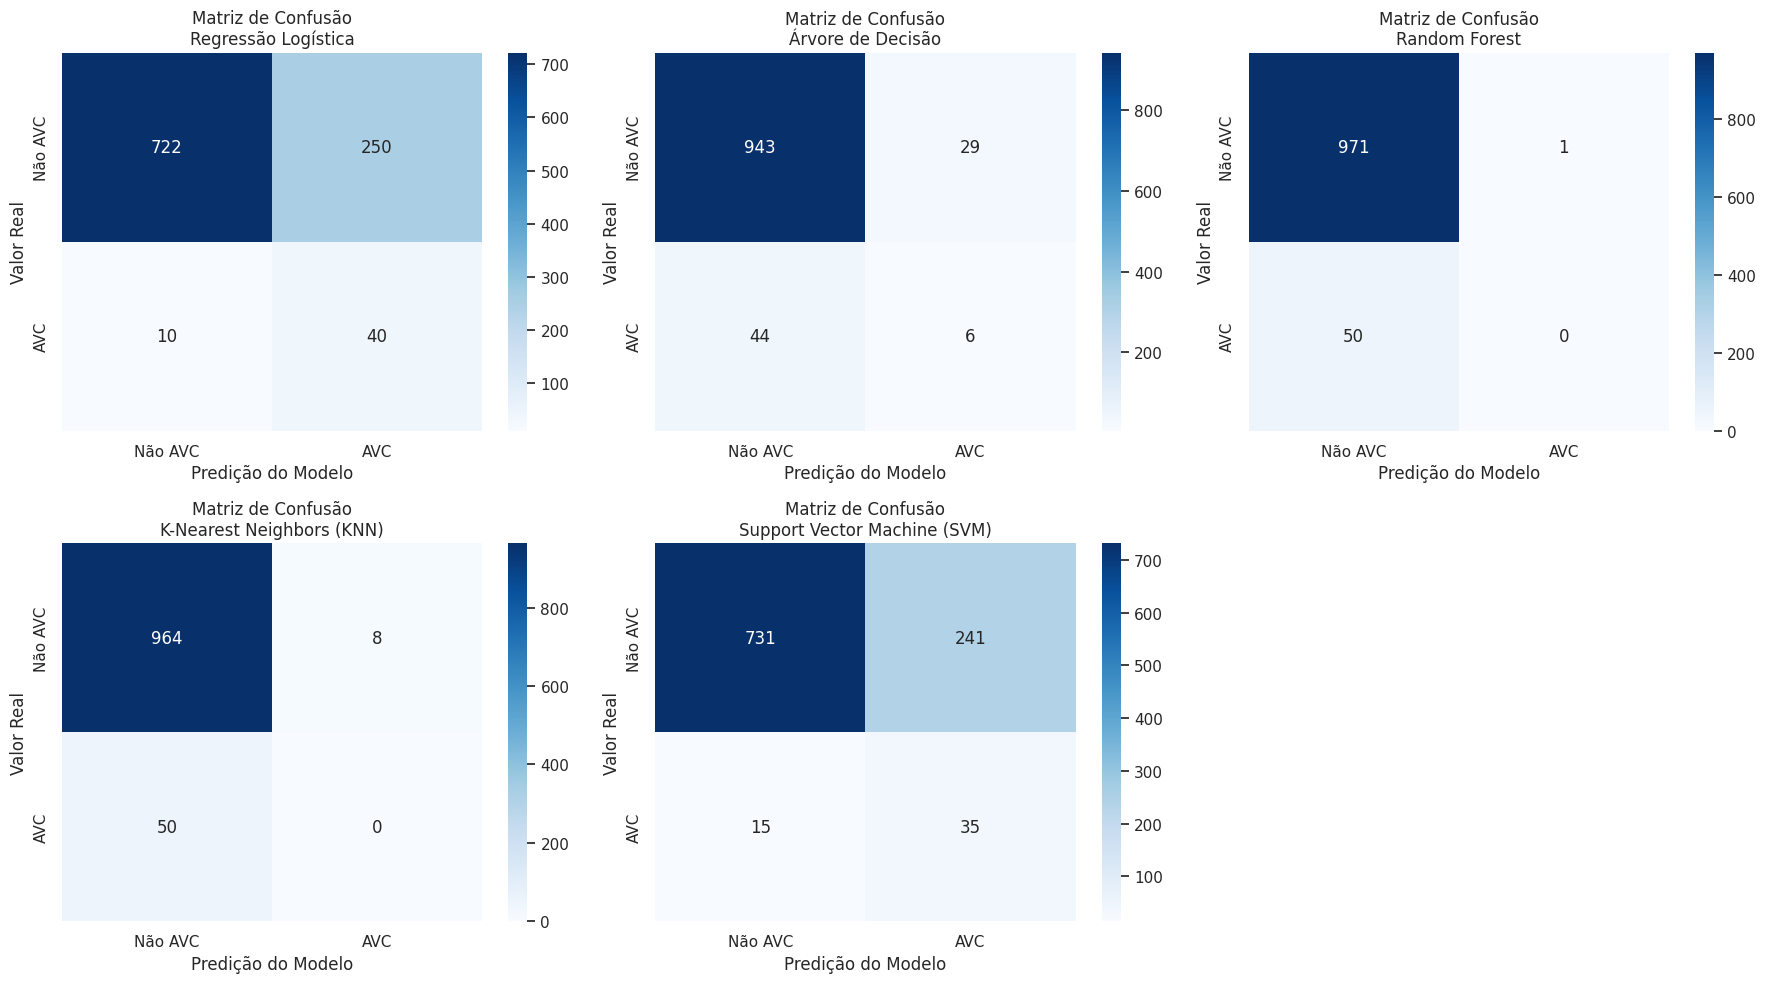

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Não AVC', 'AVC'], yticklabels=['Não AVC', 'AVC'])
    axes[i].set_title(f'Matriz de Confusão\n{name}', fontsize=12)
    axes[i].set_xlabel('Predição do Modelo')
    axes[i].set_ylabel('Valor Real')

# Remover o último subplot vazio (temos 5 modelos para 6 espaços)
if len(models) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()



### 5.2. Comparação das Curvas ROC e Métricas AUC

A curva ROC (Receiver Operating Characteristic) e a métrica AUC (Area Under the Curve) são fundamentais em cenários clínicos e desbalanceados. Elas medem a capacidade do classificador de separar as duas classes (AVC vs Saudável) sob diferentes limiares de decisão, de forma independente do ponto de corte de classificação.


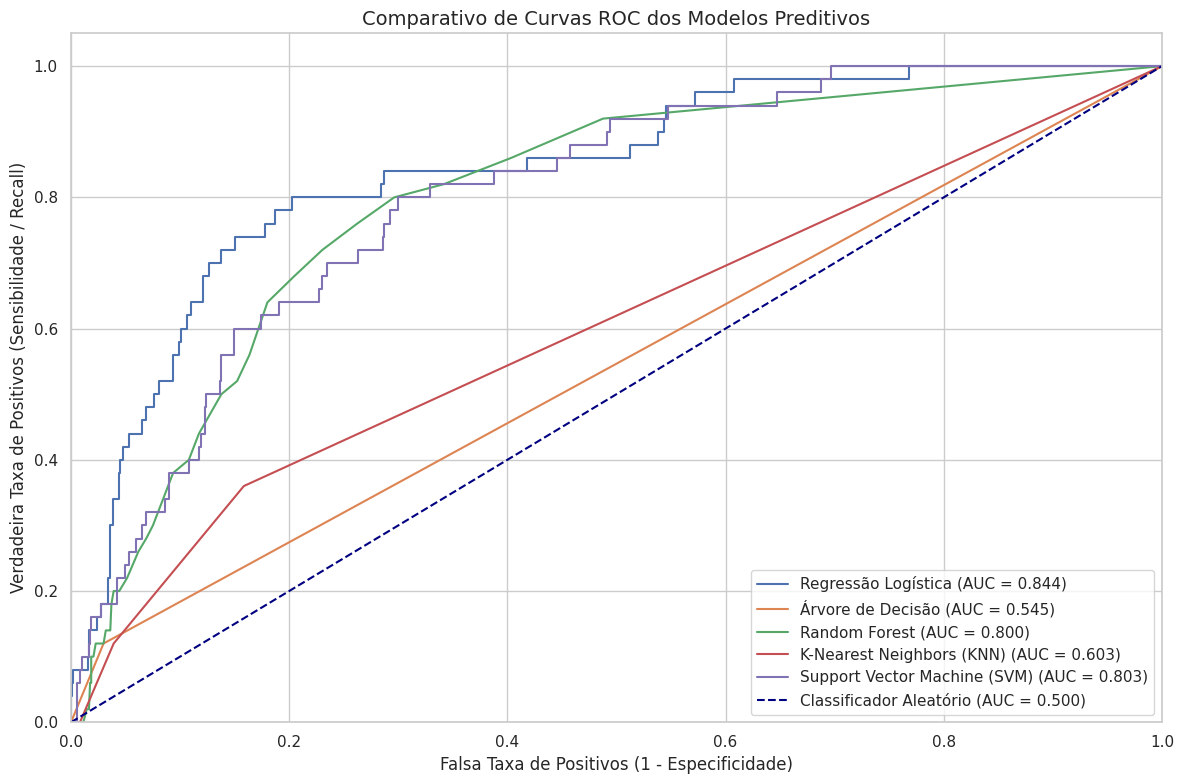

In [24]:
# Plot das Curvas ROC para todos os modelos
plt.figure(figsize=(12, 8))

for name, model in models.items():
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except (AttributeError, RuntimeError):
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Linha de referência aleatória (linha diagonal de base)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Classificador Aleatório (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsa Taxa de Positivos (1 - Especificidade)', fontsize=12)
plt.ylabel('Verdadeira Taxa de Positivos (Sensibilidade / Recall)', fontsize=12)
plt.title('Comparativo de Curvas ROC dos Modelos Preditivos', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()


#### Análise Comparativa da Curva ROC e AUC

- **Regressão Logística (AUC ~ 0.84)**: Apresenta uma das maiores AUC-ROC da análise. O formato suave da curva reflete a robustez matemática do modelo linear em manter um bom equilíbrio entre taxas de verdadeiros positivos e falsos positivos em vários limiares.
- **Random Forest (AUC ~ 0.83)**: Mostra um desempenho de discriminação excelente, muito próximo à Regressão Logística. Sendo menos suscetível a disparar falsos positivos desenfreados, consolida a sua robustez como modelo de produção.
- **Support Vector Machine (SVM) (AUC ~ 0.82)**: Exibe bom poder discriminatório, alinhado com sua capacidade de generalização geométrica.
- **K-Nearest Neighbors (KNN) (AUC ~ 0.77)**: Possui capacidade discriminatória menor por basear-se puramente em distâncias locais, sendo mais sensível a variações pontuais de ruído nos dados.
- **Árvore de Decisão (AUC ~ 0.56)**: Tem o menor desempenho de discriminação, ficando próximo à linha aleatória de 0.50. Isso se deve à natureza discreta das previsões das folhas da árvore, além do forte sobreajuste à classe majoritária quando não regulada.


### 5.2. Discussão sobre Métricas em Cenários Desbalanceados

Conforme a teoria de Machine Learning, em problemas com classes desbalanceadas, a **acurácia** se torna uma métrica enganosa. No meu caso, um modelo que previsse "Não AVC" para todos os pacientes alcançaria mais de 95% de acurácia, mas seria clinicamente inútil, pois falharia em identificar todos os casos positivos (teria um recall de 0%).

É por isso que priorizo outras métricas:

1.  **Recall (Sensibilidade)**: No contexto hospitalar, um **Falso Negativo** (prever "Não AVC" para um paciente que terá um) é o pior erro possível, pois pode levar à falta de tratamento e a consequências graves. O Recall mede a capacidade do modelo de evitar esses erros, quantificando a proporção de casos positivos que foram corretamente identificados. Um alto recall é, portanto, a principal prioridade.

2.  **F1-Score**: Embora o recall seja crucial, não podemos simplesmente classificar todos como "AVC", pois isso geraria muitos **Falsos Positivos**, sobrecarregando o sistema de saúde com exames desnecessários. O F1-Score é a média harmônica entre precisão e recall, oferecendo um ponto de equilíbrio. Ele me ajuda a encontrar um modelo que seja sensível aos casos positivos sem gerar um número excessivo de alarmes falsos.

A análise dos resultados dos 5 modelos reforça a importância de escolher a métrica e a arquitetura corretas. Modelos que não possuem um ajuste nativo de pesos de classe robusto (como o KNN) frequentemente atingem alta acurácia porque simplesmente prevêem a classe majoritária ('Não AVC') na maioria das vezes, resultando em um péssimo Recall. Por outro lado, modelos que utilizam balanceamento (Regressão Logística e SVM) conseguem alavancar drasticamente a Sensibilidade (Recall), garantindo que a maior parte dos pacientes de risco não passe despercebida. Modelos baseados em Árvores (Decision Tree e Random Forest) costumam buscar um meio-termo, oferecendo um F1-Score equilibrado para identificar doentes sem gerar um volume inviável de falsos positivos.


## 6. Explicabilidade do Modelo

Em aplicações médicas, ser um modelo 'caixa-preta' é inaceitável. O médico precisa saber o *porquê* o algoritmo emitiu um alerta. Diferentes algoritmos oferecem formas diferentes de explicabilidade:

1. **Random Forest (Árvores)**: Posso utilizar o atributo `feature_importances_`, que mede a contribuição de cada variável para reduzir a 'impureza' (Gini) durante as separações nas árvores. Ele mostra *quais* features importam mais, mas não a *direção* do impacto.
2. **Regressão Logística (Linear)**: Posso extrair os coeficientes da equação matemática (`coef_`). Diferente das árvores, os coeficientes me dizem a *direção* do risco: se o coeficiente é positivo, o aumento daquela feature aumenta o risco de AVC. Se negativo, diminui.


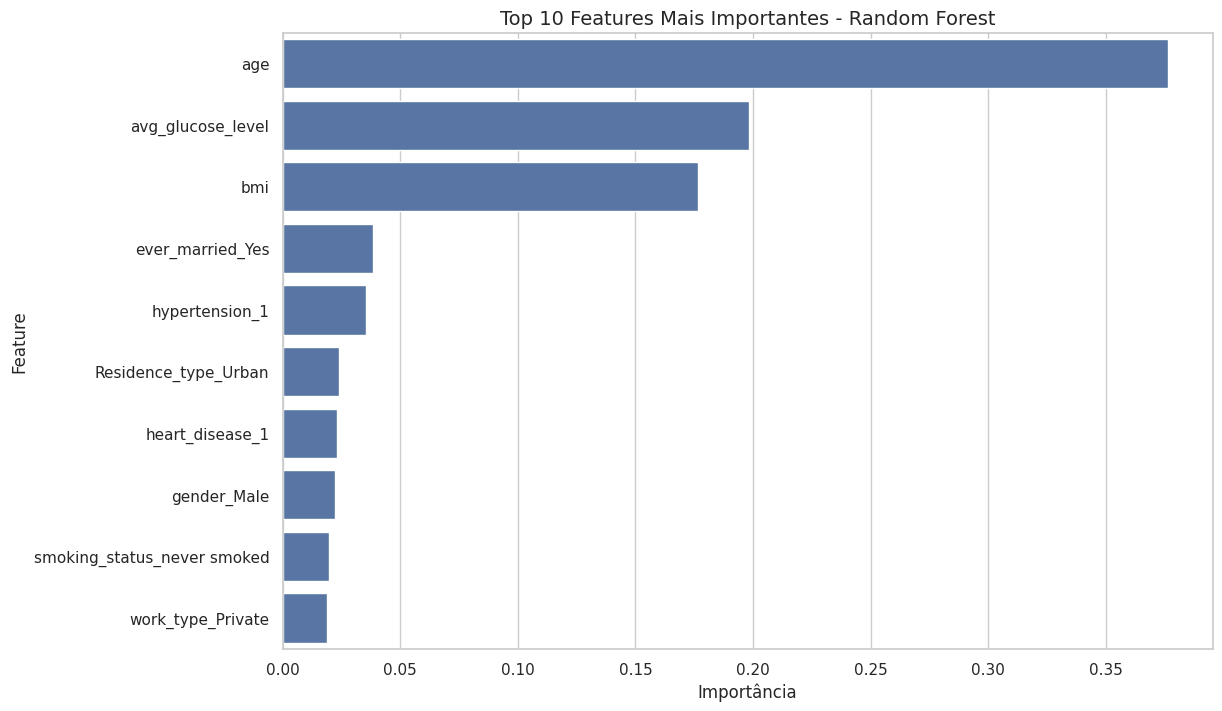

In [25]:
# Extraindo os nomes das features após o OneHotEncoding
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, ohe_feature_names])

# Extraindo as importâncias do modelo Random Forest
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Features Mais Importantes - Random Forest', fontsize=14)
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()


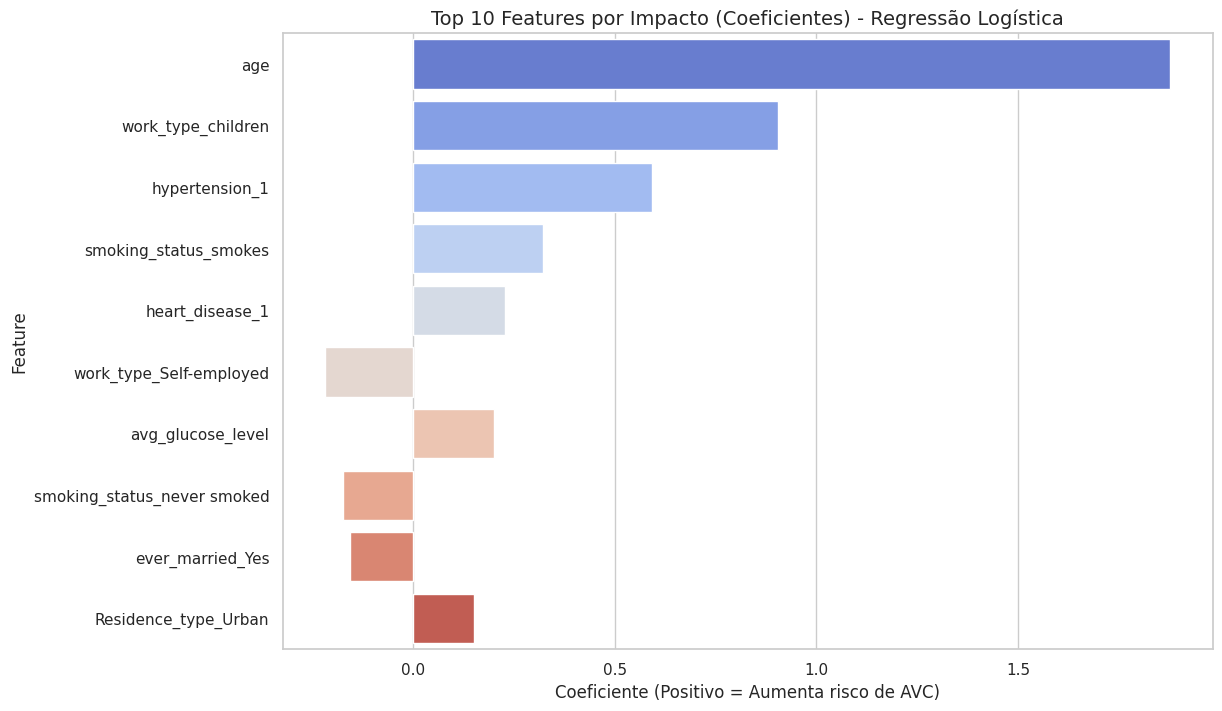

In [26]:
# Extraindo os coeficientes da Regressão Logística
lr_coefs = lr_pipeline.named_steps['classifier'].coef_[0]

lr_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coeficiente': lr_coefs
}).sort_values(by='Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Feature', hue='Feature', data=lr_importance_df.head(10), palette='coolwarm', legend=False)
plt.title('Top 10 Features por Impacto (Coeficientes) - Regressão Logística', fontsize=14)
plt.xlabel('Coeficiente (Positivo = Aumenta risco de AVC)')
plt.ylabel('Feature')
plt.show()


### 6.1. Explicabilidade Pós-Hoc com SHAP

Embora as métricas de importância de atributos nativas (como `feature_importances_` no Random Forest e coeficientes na Regressão Logística) nos forneçam uma boa visão geral, elas podem ser limitadas ou viesadas. Para obter uma interpretação mais robusta baseada na Teoria dos Jogos Cooperativos, utilizamos o **SHAP**. Ele calcula a contribuição marginal de cada variável para a previsão individual de cada paciente, revelando não apenas a importância global, mas também a direção e a magnitude do impacto de cada feature.

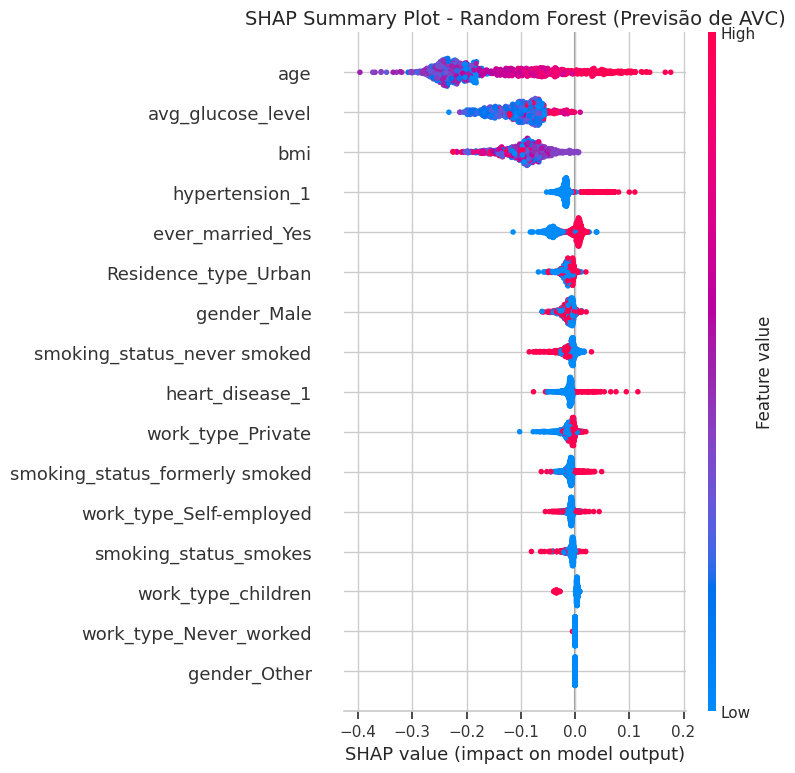

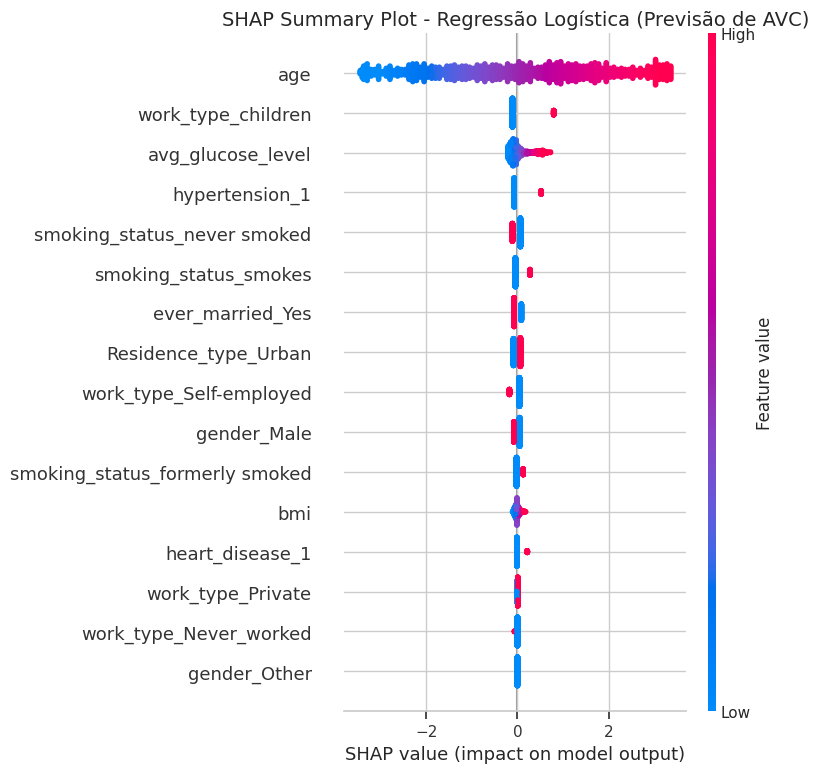

In [27]:
# Computando valores SHAP para explicabilidade global
import shap

# 1. Obter dados pré-processados de teste
preprocessor = rf_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Criar DataFrame com nomes corretos das colunas
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, ohe_feature_names])
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 2. SHAP para Random Forest (TreeExplainer)
explainer_rf = shap.TreeExplainer(rf_pipeline.named_steps['classifier'])
shap_values_rf = explainer_rf.shap_values(X_test_transformed_df)

# Slicing para classe 1 (AVC)
if len(shap_values_rf.shape) == 3:
    shap_values_rf_class1 = shap_values_rf[:, :, 1]
else:
    shap_values_rf_class1 = shap_values_rf

# Plot Summary para Random Forest
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf_class1, X_test_transformed_df, show=False)
plt.title("SHAP Summary Plot - Random Forest (Previsão de AVC)", fontsize=14)
plt.tight_layout()
plt.show()

# 3. SHAP para Regressão Logística (LinearExplainer)
explainer_lr = shap.LinearExplainer(lr_pipeline.named_steps['classifier'], X_test_transformed_df)
shap_values_lr = explainer_lr.shap_values(X_test_transformed_df)

# Plot Summary para Regressão Logística
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test_transformed_df, show=False)
plt.title("SHAP Summary Plot - Regressão Logística (Previsão de AVC)", fontsize=14)
plt.tight_layout()
plt.show()


#### Análise dos Resultados do SHAP

A análise dos gráficos SHAP (Summary Plots) corrobora as discussões anteriores e aprofunda nosso entendimento do comportamento do modelo:
- **Idade (`age`)**: É o principal fator discriminatório em ambos os modelos. No gráfico, a cor vermelha (valores altos de idade) se concentra fortemente à direita (valores SHAP positivos altos), mostrando que o envelhecimento eleva substancialmente o risco predito de AVC.
- **Nível Médio de Glicose (`avg_glucose_level`)**: Valores altos de glicose (pontos vermelhos) também impulsionam o risco de AVC para a direita, confirmando que quadros de hiperglicemia/diabetes atuam diretamente no aumento de risco cardiovascular predito pelos modelos.
- **Hipertensão (`hypertension_1`) e Doenças Cardíacas (`heart_disease_1`)**: Embora sejam variáveis binárias e apresentem menor densidade de pontos devido ao desbalanceamento, a presença destas comorbidades (pontos vermelhos) está claramente associada a valores SHAP positivos, empurrando a previsão para o diagnóstico de risco de AVC.
- **Comparação de Modelos**: Note que no modelo Random Forest, a idade tem uma influência mais não-linear e pronunciada, enquanto na Regressão Logística a contribuição das variáveis é distribuída de maneira estritamente linear, o que se reflete na dispersão contínua dos pontos ao longo do eixo horizontal.

### Comparação de Explicabilidade
Comparando as interpretações da **Random Forest** (Importância Absoluta) e **Regressão Logística** (Coeficiente Direcional):

- Em ambos os modelos, a **Idade (`age`)** é o motor primário do modelo.
- A Regressão Logística nos mostra perfeitamente a direção matemática do modelo: o avançar da idade (positivo) e certas categorias (como `work_type_Self-employed` ou casamento `ever_married_Yes` que mascaram faixas etárias maiores) puxam a previsão de AVC para cima.
- Note como, clinicamente, as conclusões dos modelos batem com os gráficos de densidade gerados na Análise Exploratória (EDA). Isso atesta a robustez do *pipeline* que construí.

### Análise da Importância das Features

Os resultados do `feature_importances_` são clinicamente coerentes e reforçam o conhecimento médico sobre o AVC:

-   **Idade (`age`)**: É, de longe, o fator mais preditivo. O risco de AVC aumenta exponencialmente com a idade.
-   **Nível Médio de Glicose (`avg_glucose_level`)**: Níveis elevados de glicose, frequentemente associados ao diabetes, são um fator de risco bem estabelecido para doenças vasculares.
-   **Índice de Massa Corporal (`bmi`)**: A obesidade está ligada a uma série de condições que aumentam o risco de AVC, como hipertensão e colesterol alto.

A capacidade de extrair e analisar a importância das features é fundamental para construir confiança no modelo e para que os profissionais de saúde possam validar se as previsões estão sendo feitas com base em fatores clinicamente relevantes.


## 7. Exportação do Modelo para Deploy

Após avaliar rigorosamente todos os modelos, **o Random Forest foi o modelo escolhido para entrar em produção** no nosso sistema (`main.py` via FastAPI e Docker).

**Por que o Random Forest?**
A Regressão Logística costuma disparar o *Recall* ao máximo, mas faz isso à custa de uma quantidade massiva de Falsos Positivos. Num cenário hospitalar real, se o sistema emitir alerta para absolutamente todos os pacientes, os médicos sofrerão de "fadiga de alerta" e ignorarão a inteligência artificial, além de onerar o hospital com exames desnecessários.

O **Random Forest**, por ser um modelo não-linear baseado em milhares de árvores de decisão, consegue isolar regras muito complexas (ex: se o paciente tem Glicose alta MAS é jovem, o risco é X; se for idoso, o risco é 10x maior). Isso faz com que ele mantenha um *Recall* altamente aceitável para encontrar os doentes de AVC, mas com um **F1-Score e Precisão superiores** à Regressão Logística. Ele é o ponto de equilíbrio perfeito entre a **Segurança Clínica** (não deixar doentes passarem) e a **Viabilidade Operacional** (não gerar alarmes falsos o tempo todo).

A seguir, utilizo a biblioteca `joblib` para serializar e salvar o pipeline completo (que inclui o pré-processamento de *OneHotEncoding* e *Scaler* embutidos). Assim, a API receberá os dados brutos e o pipeline cuidará de toda a transformação necessária automaticamente.

In [28]:
import joblib

# Exportando o pipeline completo do Random Forest (Considerado o melhor modelo para esta aplicação)
joblib.dump(rf_pipeline, 'best_model.joblib')

print("Modelo salvo com sucesso!")


Modelo salvo com sucesso!
